In [1]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [4]:
os.makedirs("../data", exist_ok=True)
os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

print("Project folders are ready.")

Project folders are ready.


In [5]:
import torchvision
import sklearn
import pandas

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)

torch: 2.10.0
torchvision: 0.25.0
numpy: 2.4.2
sklearn: 1.8.0
pandas: 3.0.1


In [6]:
image_size = 224

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
train_dataset = datasets.Flowers102(
    root="../data",
    split="train",
    download=False,
    transform=eval_transform
)

val_dataset = datasets.Flowers102(
    root="../data",
    split="val",
    download=False,
    transform=eval_transform
)

test_dataset = datasets.Flowers102(
    root="../data",
    split="test",
    download=False,
    transform=eval_transform
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1020
Val size: 1020
Test size: 6149


In [8]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Dataloaders created successfully.")

Dataloaders created successfully.


In [9]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: [50, 62, 15, 96, 28, 7, 87, 73, 13, 84]


In [10]:
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

def show_tensor_image(img_tensor, ax=None, title=None):
    img = inv_normalize(img_tensor).clamp(0, 1)
    img = img.permute(1, 2, 0).cpu().numpy()
    
    if ax is None:
        plt.imshow(img)
        if title is not None:
            plt.title(title)
        plt.axis("off")
    else:
        ax.imshow(img)
        if title is not None:
            ax.set_title(title)
        ax.axis("off")

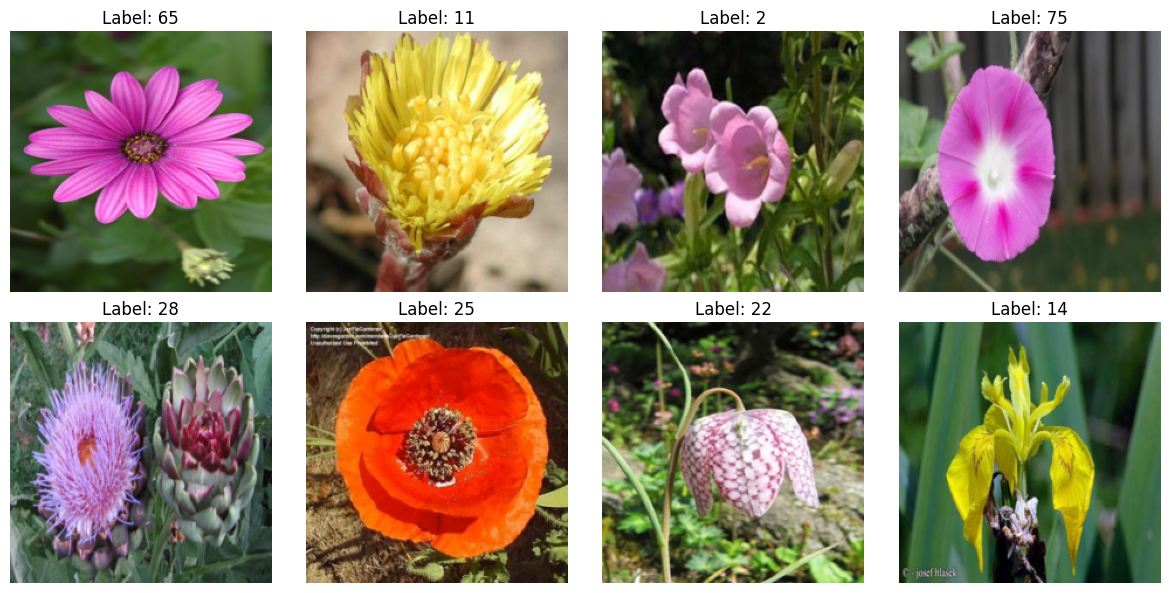

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flatten():
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]
    show_tensor_image(img, ax=ax, title=f"Label: {label}")

plt.tight_layout()
plt.show()

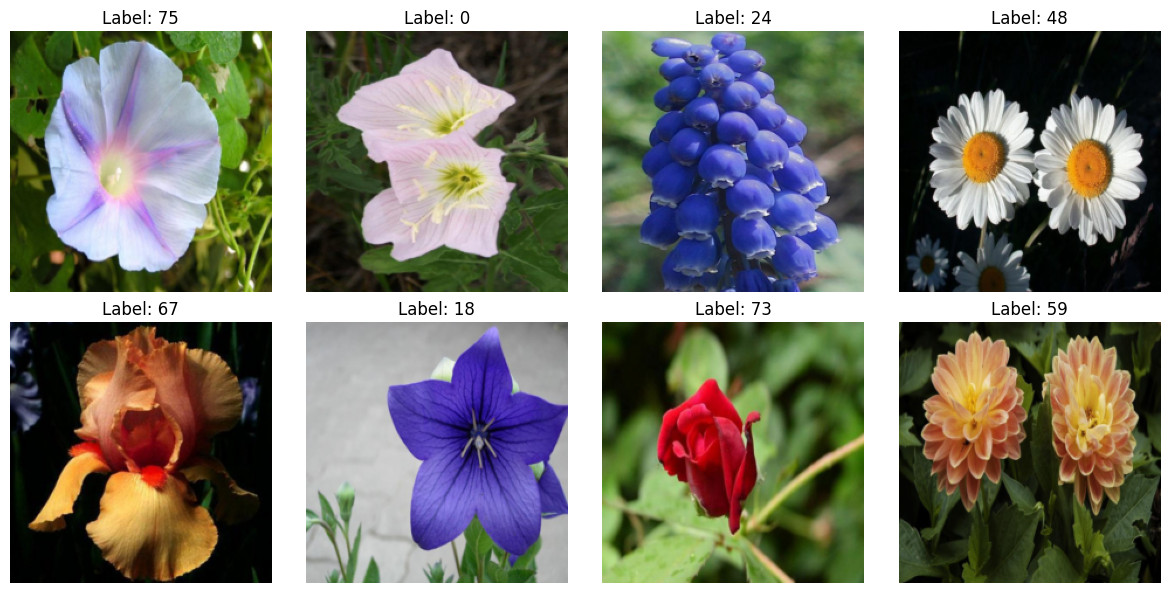

In [12]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    show_tensor_image(images[i], ax=ax, title=f"Label: {labels[i].item()}")

plt.tight_layout()
plt.show()

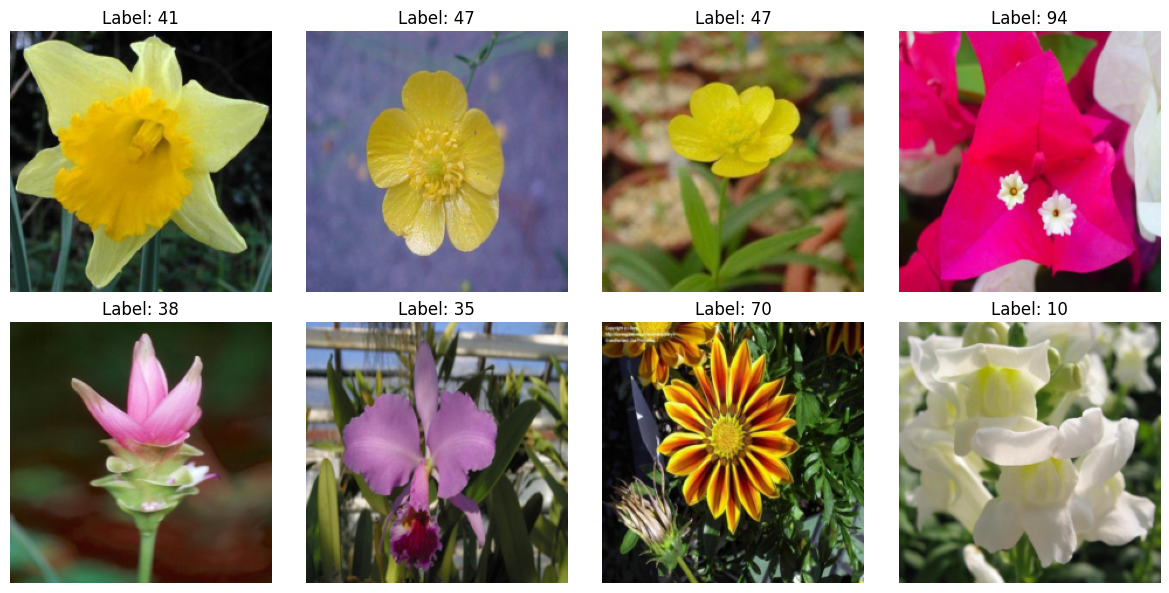

Saved figure to ../figures/flowers102_samples.png


In [13]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    show_tensor_image(images[i], ax=ax, title=f"Label: {labels[i].item()}")

plt.tight_layout()
plt.savefig("../figures/flowers102_samples.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure to ../figures/flowers102_samples.png")

## 4. SimCLR Self-Supervised Pretraining

In [14]:
# SimCLR augmentation

class SimCLRTransform:
    def __init__(self, image_size=224):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([
                transforms.ColorJitter(0.4,0.4,0.4,0.1)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

    def __call__(self, x):
        x1 = self.transform(x)
        x2 = self.transform(x)
        return x1, x2

In [15]:
from torchvision import datasets, transforms
from torch.utils.data import Dataset, ConcatDataset, DataLoader

In [16]:
raw_train_dataset = datasets.Flowers102(
    root="../data",
    split="train",
    download=False,
    transform=None
)

raw_val_dataset = datasets.Flowers102(
    root="../data",
    split="val",
    download=False,
    transform=None
)

print(len(raw_train_dataset), len(raw_val_dataset))

1020 1020


In [17]:
from torch.utils.data import Dataset, ConcatDataset

class SSLDataset(Dataset):

    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        img, _ = self.base_dataset[idx]

        x1, x2 = self.transform(img)

        return x1, x2


ssl_transform = SimCLRTransform(image_size=image_size)

ssl_base_dataset = ConcatDataset([
    raw_train_dataset,
    raw_val_dataset
])

ssl_dataset = SSLDataset(ssl_base_dataset, ssl_transform)

print("SSL dataset size:", len(ssl_dataset))

SSL dataset size: 2040


In [18]:
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

print("SSL dataloader ready")

SSL dataloader ready


In [19]:
x1, x2 = next(iter(ssl_loader))

print(x1.shape)
print(x2.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])


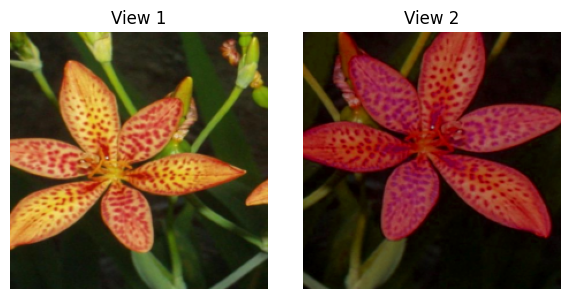

In [20]:
def show_ssl_pair(x1, x2, idx=0):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    show_tensor_image(x1[idx], ax=axes[0], title="View 1")
    show_tensor_image(x2[idx], ax=axes[1], title="View 2")
    plt.tight_layout()
    plt.show()

x1, x2 = next(iter(ssl_loader))
show_ssl_pair(x1, x2, idx=0)

In [21]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()

        backbone = models.resnet18(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.encoder = backbone
        self.projector = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, feature_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z

In [22]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z = torch.cat([z1, z2], dim=0)  # [2B, D]
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, device=z.device).bool()
    sim = sim.masked_fill(mask, -1e9)

    targets = torch.arange(batch_size, device=z.device)
    targets = torch.cat([targets + batch_size, targets], dim=0)

    loss = F.cross_entropy(sim, targets)
    return loss

In [23]:
simclr_model = SimCLRModel(feature_dim=128).to(device)

x1, x2 = next(iter(ssl_loader))
x1 = x1.to(device)
x2 = x2.to(device)

_, z1 = simclr_model(x1)
_, z2 = simclr_model(x2)

print("z1 shape:", z1.shape)
print("z2 shape:", z2.shape)

test_loss = nt_xent_loss(z1, z2)
print("Test loss:", test_loss.item())

z1 shape: torch.Size([32, 128])
z2 shape: torch.Size([32, 128])
Test loss: 4.097221374511719


In [24]:
from tqdm import tqdm

def train_simclr(model, loader, epochs=3, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for x1, x2 in pbar:
            x1 = x1.to(device)
            x2 = x2.to(device)

            _, z1 = model(x1)
            _, z2 = model(x2)

            loss = nt_xent_loss(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / len(loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1}: avg loss = {epoch_loss:.4f}")

    return loss_history

In [68]:
simclr_model = SimCLRModel(feature_dim=128)

simclr_loss_history = train_simclr(
    simclr_model,
    ssl_loader,
    epochs=60,
    lr=1e-3
)

Epoch 1/60: 100%|██████████| 63/63 [00:54<00:00,  1.16it/s, loss=3.4233]


Epoch 1: avg loss = 3.7146


Epoch 2/60: 100%|██████████| 63/63 [00:52<00:00,  1.20it/s, loss=3.2883]


Epoch 2: avg loss = 3.4301


Epoch 3/60: 100%|██████████| 63/63 [00:52<00:00,  1.21it/s, loss=3.2858]


...

Epoch 58: avg loss = 2.4605


Epoch 59/60: 100%|██████████| 63/63 [00:54<00:00,  1.15it/s, loss=2.4567]


Epoch 59: avg loss = 2.4637


Epoch 60/60: 100%|██████████| 63/63 [00:54<00:00,  1.15it/s, loss=2.4197]

Epoch 60: avg loss = 2.4506


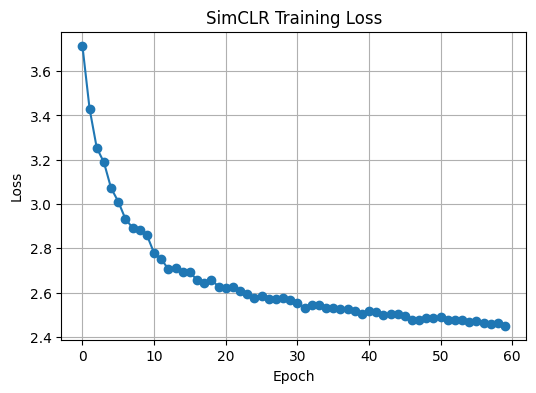

In [69]:
plt.figure(figsize=(6, 4))
plt.plot(simclr_loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimCLR Training Loss")
plt.grid(True)
plt.show()

In [70]:
torch.save(simclr_model.state_dict(), "../checkpoints/simclr_resnet18.pth")
print("Saved checkpoint to ../checkpoints/simclr_resnet18.pth")

Saved checkpoint to ../checkpoints/simclr_resnet18.pth


## 5. Feature Extraction and Downstream Evaluation

In [71]:
def extract_features(model, dataset, batch_size=32):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Extracting features"):
            x = x.to(device)

            # SimCLR model: use model.encoder
            if hasattr(model, "encoder"):
                h = model.encoder(x)
            # Plain ResNet baseline: use model directly
            else:
                h = model(x)

            features.append(h.cpu())
            labels.append(y)

    features = torch.cat(features, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()

    return features, labels

In [72]:
train_features, train_labels = extract_features(simclr_model, train_dataset)
val_features, val_labels = extract_features(simclr_model, val_dataset)
test_features, test_labels = extract_features(simclr_model, test_dataset)

print("Train features:", train_features.shape)
print("Val features:", val_features.shape)
print("Test features:", test_features.shape)

Extracting features: 100%|██████████| 193/193 [00:30<00:00,  6.23it/s]

Train features: (1020, 512)
Val features: (1020, 512)
Test features: (6149, 512)


In [73]:
X_train = np.concatenate([train_features, val_features], axis=0)
y_train = np.concatenate([train_labels, val_labels], axis=0)

X_test = test_features
y_test = test_labels

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2040, 512)
y_train: (2040,)
X_test: (6149, 512)
y_test: (6149,)


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

linear_clf = LogisticRegression(max_iter=2000)

linear_clf.fit(X_train, y_train)
linear_pred = linear_clf.predict(X_test)

linear_acc = accuracy_score(y_test, linear_pred)
print("Linear Probe Test Accuracy:", linear_acc)

Linear Probe Test Accuracy: 0.3376158724995934


In [75]:
random_encoder = models.resnet18(weights=None)
random_encoder.fc = nn.Identity()
random_encoder = random_encoder.to(device)

In [76]:
random_encoder = models.resnet18(weights=None)
random_encoder.fc = nn.Identity()
random_encoder = random_encoder.to(device)

In [77]:
random_train_features, _ = extract_features(random_encoder, train_dataset)
random_val_features, _ = extract_features(random_encoder, val_dataset)
random_test_features, _ = extract_features(random_encoder, test_dataset)

Extracting features: 100%|██████████| 193/193 [00:30<00:00,  6.36it/s]


In [78]:
X_train_rand = np.concatenate([random_train_features, random_val_features], axis=0)
X_test_rand = random_test_features

In [79]:
rand_clf = LogisticRegression(max_iter=2000)

rand_clf.fit(X_train_rand, y_train)
rand_pred = rand_clf.predict(X_test_rand)

rand_acc = accuracy_score(y_test, rand_pred)

print("Random Encoder Accuracy:", rand_acc)

Random Encoder Accuracy: 0.29858513579443813


In [50]:
import pandas as pd

In [80]:
results = pd.DataFrame({
    "Method": [
        "Random Encoder + Linear Probe",
        "SimCLR + Linear Probe"
    ],
    "Test Accuracy": [
        rand_acc,
        linear_acc
    ]
})

results

,Method,Test Accuracy
0,Random Encoder + Linear Probe,0.298585
1,SimCLR + Linear Probe,0.337616


In [84]:
import pandas as pd

linear_acc_60 = linear_acc

results = pd.DataFrame({
    "Method": [
        "Random Encoder + Linear Probe",
        "SimCLR (3 epochs) + Linear Probe",
        "SimCLR (10 epochs) + Linear Probe",
        "SimCLR (60 epochs) + Linear Probe",
    ],
    "Test Accuracy": [
        rand_acc,
        0.16913319238900634,
        0.18767279232395512,
        linear_acc_60
    ]
})

results

,Method,Test Accuracy
0,Random Encoder + Linear Probe,0.298585
1,SimCLR (3 epochs) + Linear Probe,0.169133
2,SimCLR (10 epochs) + Linear Probe,0.187673
3,SimCLR (60 epochs) + Linear Probe,0.337616


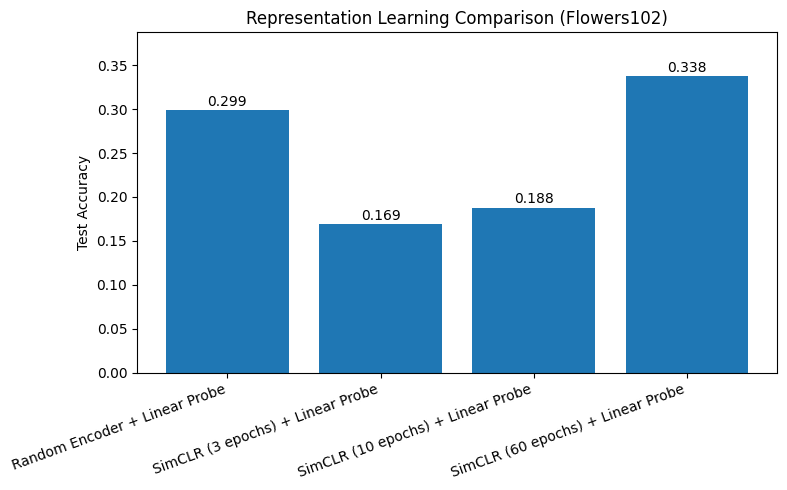

Saved to figures/method_comparison.png


In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(results["Method"], results["Test Accuracy"])

plt.ylabel("Test Accuracy")
plt.title("Representation Learning Comparison (Flowers102)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, max(results["Test Accuracy"]) + 0.05)

for bar, value in zip(bars, results["Test Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig("../figures/method_comparison.png", dpi=200)
plt.show()

print("Saved to figures/method_comparison.png")

In [87]:
results.to_csv("../results/comparison_results.csv", index=False)
print("Saved results to results/comparison_results.csv")

Saved results to results/comparison_results.csv
